# 🦢 Modelo 6: Pre-trained Swin Transformer (Transfer Learning)

En este notebook utilizamos la técnica de **Transfer Learning** con un **Swin Transformer pre-entrenado** en ImageNet. Esto suele dar mejores resultados que entrenar desde cero, ya que el modelo ya conoce formas, texturas y patrones básicos.

Utilizamos la librería `tfswin` para acceder a los pesos oficiales.

---

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Silenciar warnings
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from tensorflow.keras.metrics import AUC

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_swin_pretrained as swin_model


In [2]:
# Configurar GPUs para crecimiento de memoria dinámico
gpus = tf.config.list_physical_devices('GPU')[0]


## 1. Carga de Datos
**IMPORTANTE**: Los modelos pre-entrenados del Swin Transformer esperan imágenes de **3 canales (RGB)** y, preferiblemente, un tamaño de **224x224**. Vamos a ajustar el dataloader para esto.

In [4]:
# Descargar/Localizar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")
data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

# Configuración para Transfer Learning
IMG_SIZE = (224, 224) # Tamaño estándar para Swin pre-entrenado
BATCH_SIZE = 32       # Los Transformers consumen mucha memoria GPU; bajamos el batch si es necesario

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',          # Swin pre-entrenado requiere 3 canales (RGB)
    label_mode='categorical',   # Para la métrica AUC
    train_subset_fraction=1,  # Subset pequeño para probar la arquitectura rápido
    optimize=True
)

⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (224, 224)
   • Batch size: 32
   • Label mode: categorical
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
✅ Data loader de entrenamiento creado (con optimización)

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado (con optimización)

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado (con optimización)

📊 RESUMEN DE DATASETS
Train:      2392 batches
Validation: 684 batches
Test:       342 batches



## 2. Definición del Modelo Pre-entrenado
Cargamos `SwinTransformerTiny` con pesos de `ImageNet`.

In [5]:
# Hiperparámetros para Transfer Learning
INITIAL_LR = 1e-5  # Bajamos el LR para fine-tuning total
DROPOUT = 0.4

# Crear arquitectura con pesos pre-entrenados
model = swin_model.create_pretrained_swin(
    input_shape=(224, 224, 3), # RGB
    num_classes=4, 
    dropout_rate=DROPOUT,
    use_augmentation=True  #Data Augmentation integrado aquí
)

# Compilar
metrics = [
    'accuracy', 
    AUC(name='auc', multi_label=True)
]

model = swin_model.compile_swin_model(
    model, 
    learning_rate=INITIAL_LR, 
    metrics=metrics
)

model.summary()

Model: "PretrainedSwinOCT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_tiny_224 (Functional)      │ (None, 768)            │    27,519,354 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,720,318 (105.74 MB)

 Trainable params: 27,718,782 (105.74 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 3. Entrenamiento (Fine-tuning Total)
En esta fase el modelo base está **desbloqueado** y se entrena por completo.

In [6]:
EPOCHS = 50

callbacks = swin_model.get_callbacks(
    patience_stop=5, 
    patience_lr=3, 
    factor_lr=0.2
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 505s 203ms/step - accuracy: 0.8162 - auc: 0.9184 - loss: 0.5732 - val_accuracy: 0.9416 - val_auc: 0.9839 - val_loss: 0.1870 - learning_rate: 1.0000e-05
Epoch 2/50
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 458s 191ms/step - accuracy: 0.9232 - auc: 0.9755 - loss: 0.2492 - val_accuracy: 0.9496 - val_auc: 0.9894 - val_loss: 0.1507 - learning_rate: 1.0000e-05
Epoch 3/50
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 458s 192ms/step - accuracy: 0.9380 - auc: 0.9826 - loss: 0.1976 - val_accuracy: 0.9574 - val_auc: 0.9914 - val_loss: 0.1238 - learning_rate: 1.0000e-05
Epoch 4/50
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 457s 191ms/step - accuracy: 0.9463 - auc: 0.9858 - loss: 0.1694 - val_accuracy: 0.9627 - val_auc: 0.9903 - val_loss: 0.1210 - learning_rate: 1.0000e-05
Epoch 5/50
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 457s 191ms/step - accuracy: 0.9503 - auc: 0.9882 - loss: 0.1549 - val_accuracy: 0.9577 - val_auc: 0.9923 - val_loss: 0.1214 - learning_rate: 1.0000e-05
Epoch 6/50
2392/2392 ━━━━━━━━━

## 4. Visualización

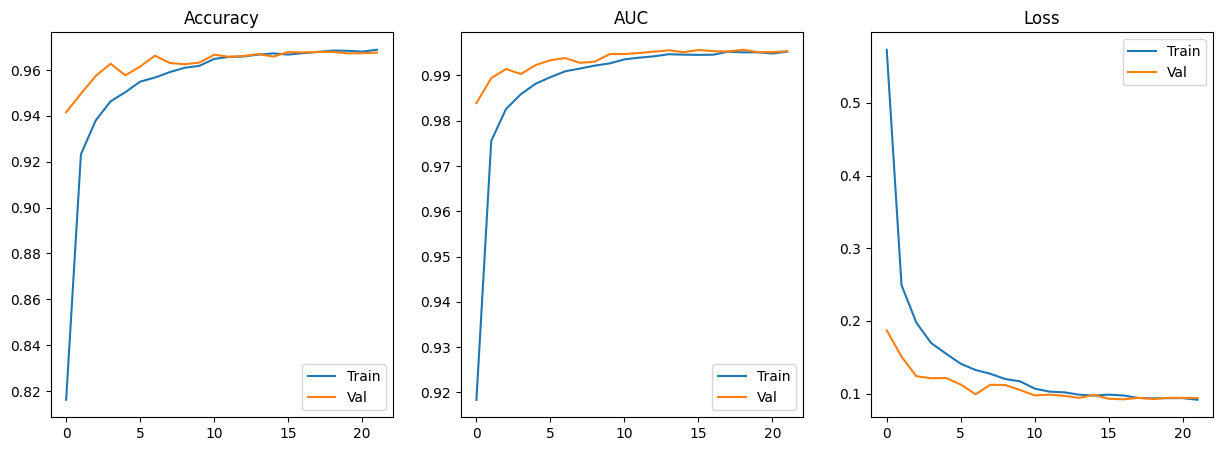

In [7]:
def plot_history(history):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(history.history['auc'], label='Train')
    plt.plot(history.history['val_auc'], label='Val')
    plt.title('AUC')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    
    plt.show()

plot_history(history)

Loss en test: 0.0986
Accuracy en test: 0.9665

AUC por clase (One-vs-Rest):
 - CNV: 0.9984
 - DME: 0.9980
 - DRUSEN: 0.9914
 - NORMAL: 0.9990

AUC Promedio (Macro): 0.9967

Reporte de clasificacion:
              precision    recall  f1-score   support

         CNV       0.99      0.95      0.97      3746
         DME       0.94      0.95      0.95      1161
      DRUSEN       0.83      0.92      0.87       887
      NORMAL       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.94      0.95      0.94     10933
weighted avg       0.97      0.97      0.97     10933



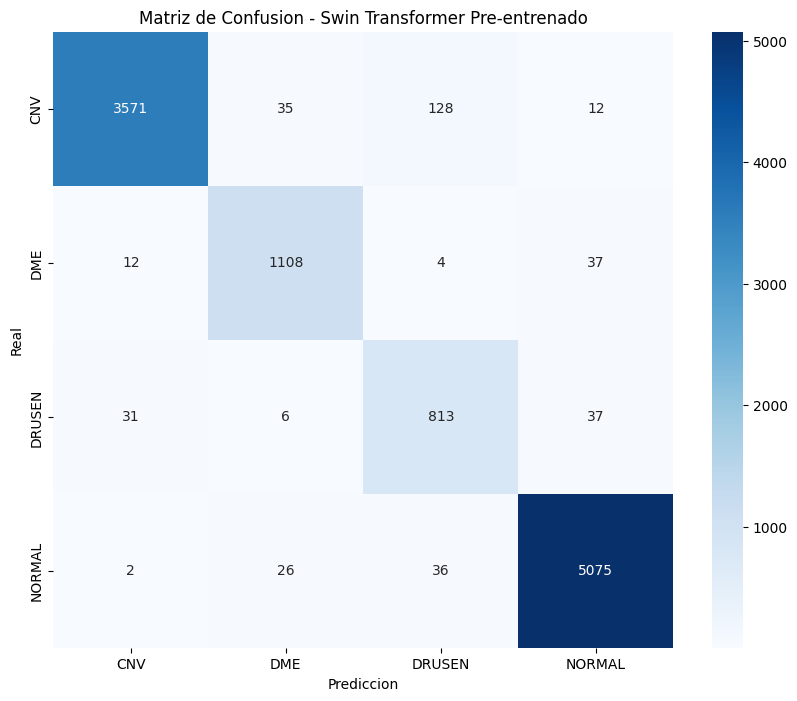

In [8]:
# --- Chunk: Evaluacion de Metricas Finales ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical

results = model.evaluate(test_ds, verbose=0)
print(f"Loss en test: {results[0]:.4f}")
print(f"Accuracy en test: {results[1]:.4f}")

y_true = []
y_probs = []

# Obtencion de predicciones
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred_labels = np.argmax(y_probs, axis=1)

# Verificar si y_true ya viene en formato One-Hot o como indices enteros
if len(y_true.shape) == 2 and y_true.shape[1] > 1:
    y_true_oh = y_true
    y_true_labels = np.argmax(y_true, axis=1)
else:
    y_true_labels = y_true
    y_true_oh = to_categorical(y_true, num_classes=len(class_names))

# Calculo de AUC por clase
print("\nAUC por clase (One-vs-Rest):")
auc_scores = []
for i, class_name in enumerate(class_names):
    auc = roc_auc_score(y_true_oh[:, i], y_probs[:, i])
    auc_scores.append(auc)
    print(f" - {class_name}: {auc:.4f}")

print(f"\nAUC Promedio (Macro): {np.mean(auc_scores):.4f}")

# Reporte de Clasificacion
print("\nReporte de clasificacion:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Matriz de Confusion
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion - Swin Transformer Pre-entrenado')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.show()
